## EDA Basenotes acquired colognes


In [110]:
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [121]:
conn = sqlite3.connect("/Users/gauravkumar/Downloads/cologne-recommender/data/colognes_basenotes.db")

query = """
SELECT 
    c.id, 
    c.name, 
    c.brand, 
    c.gender, 
    c.positive_reviews, 
    c.neutral_reviews, 
    c.negative_reviews,
    c.review_texts,
    GROUP_CONCAT(n.name, ', ') AS fragrance_notes
FROM colognes c
LEFT JOIN cologne_notes cn ON c.id = cn.cologne_id
LEFT JOIN notes n ON cn.note_id = n.id
GROUP BY c.id
"""
df = pd.read_sql_query(query, conn)
display(df.sample(10))

,id,name,brand,gender,positive_reviews,neutral_reviews,negative_reviews,review_texts,fragrance_notes
1566,1567,Millésime 1849,Creed (2012),Unisex,5,3,2,"[""Wow what an accomplishment. Whatever Creed i...","jasmine, vanilla, patchouli, cedarwood, bergam..."
3726,3727,A*Men Pure Tonka,Mugler (2016),Unisex,14,5,3,"[""Beautiful gourmand long lasting fragrance wi...","vanilla, patchouli, rosemary, lavender, tonka ..."
3265,3266,Cologne Royale,Christian Dior (2010),Unisex,9,2,0,"[""Garriguerrilla In Chanel shades, where did y...","bergamot, mandarin, sandalwood, orange, green ..."
3478,3479,Polo Blue,"Eau de Parfum, Ralph Lauren (2016)",Unisex,9,0,1,"[""A unique take on the blue/marine scent categ...","bergamot, vetiver, blue orris accord"
3275,3276,Monogram,Ralph Lauren (1985),Unisex,13,4,2,"[""Monogram by Ralph Lauren (1985) is a strange...","Citrus, Spice"
523,524,Spice & Black Vanilla,Cremo,Male,11,0,0,"[""I don't smell much besides warm, tastefully ...","vanilla, spices, woods, tobacco"
70,71,J'Adore,Christian Dior (1999),Unisex,54,29,21,"[""Queue music, \u201cHeavy Cross\u201d by Goss...","Ylang Ylang, Damascus Rose, Jasmine Sambac, Ja..."
1482,1483,Boundless,Amouage (2021),Unisex,7,2,1,"[""Blood orange, cardamom, ginger co2, and elem...","patchouli, vetiver, guaiac wood, cardamom, blo..."
782,783,Skin Bracer,Mennen (1931),Male,15,2,3,"[""A classic fresh scent that lingers just as l...",NaN
3639,3640,I'm Home,Lush (2016),Unisex,3,0,0,"[""A cozy burnt cocoa scent. Unisex. A bit resi...","benzoin, tonka, vanilla absolute, cocoa absolute"


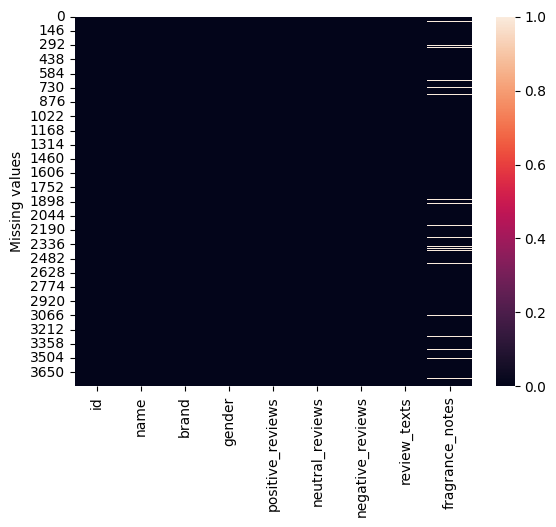

In [102]:
ax = plt.axes()
sns.heatmap(df.isna(), ax=ax)
plt.ylabel('Missing values')
plt.show()

In [103]:

df['fragrance_notes'].isna().sum()

np.int64(209)

In [108]:
(df['review_texts']== "[]").sum()

np.int64(328)

In [124]:
df['review_texts'] = df['review_texts'].mask(df['review_texts'].apply(lambda x:x == "[]"), np.nan)

In [125]:
df['review_texts'].isna().sum()

np.int64(328)

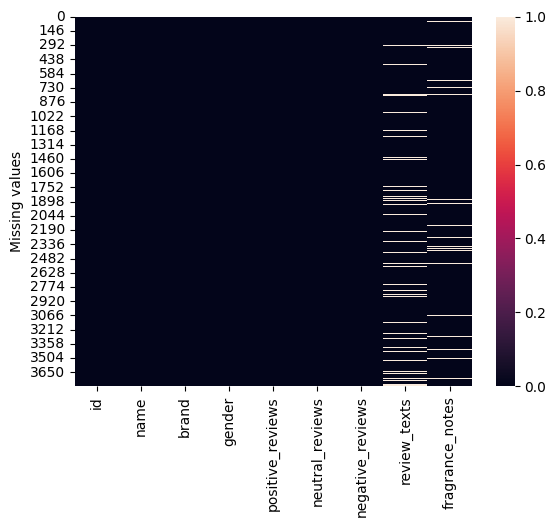

In [126]:
ax = plt.axes()
sns.heatmap(df.isna(), ax=ax)
plt.ylabel('Missing values')
plt.show()

In [131]:

df[df.isna().any(axis=1)].sample(5).style.highlight_null(color='red')

,id,name,brand,gender,positive_reviews,neutral_reviews,negative_reviews,review_texts,fragrance_notes
2067,2068,Thames Yachting Club,An unexpected error occurred. Please try again later.,Unisex,0,0,0,nan,nan
3509,3510,Mon 004,Al Musbah (2021),Unisex,0,0,0,nan,"jasmine, amber, apple, honey, tuberose, fruits, cranberry"
3750,3751,Fresh Cream Warm Cashmere,Philosophy (2018),Unisex,0,0,0,nan,"sandalwood, orchid, tangerine, cashmere woods, skin musk, vanilla bean"
1756,1757,God is a Woman,Ariana Grande (2021),Unisex,0,0,0,nan,"vanilla, cedarwood, iris, turkish rose, pear, ambrette"
2819,2820,Ancestry in Paris,Amway,Male,0,0,0,nan,"peach, white musk, tuberose, sea breeze, night-blooming jasmine"


<Axes: >

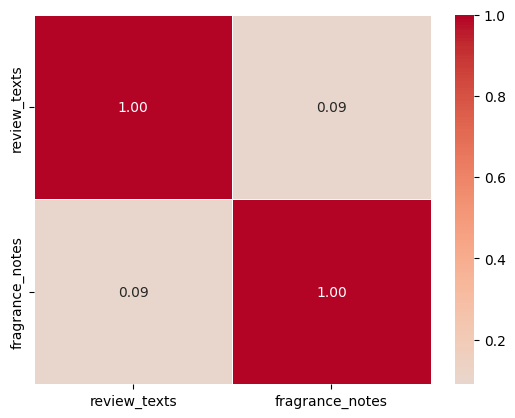

In [135]:
df_corr= df.isna().corr()
nan_cols = df.columns[df.isna().any()]
corr_mat = df_corr.loc[nan_cols, nan_cols]
sns.heatmap(corr_mat, cmap='coolwarm', center=0, annot=True, fmt='.2f', linewidths=0.5)


In [ ]:
df['review_texts'].isna().corr(df['fragrance_notes'].isna()) # no correlation whatsoever

np.float64(0.09013855111272899)

In [142]:
(537/3639)*100

14.756801319043694

In [ ]:
zero_neg_count = (df['negative_reviews'] == 0).sum()
print(f"Number of rows with zero negative reviews: {zero_neg_count}")
zero_pos_count = (df['positive_reviews'] == 0).sum()
print(f"Number of rows with zero positive reviews: {zero_pos_count}")
zero_neu_count = (df['neutral_reviews'] == 0).sum()
print(f"Number of rows with zero neutral reviews: {zero_neu_count}")
zero_all_count = (df['negative_reviews'] == 0) & (df['positive_reviews'] == 0) & (df['neutral_reviews'] == 0)
print(f"Number of rows with zero reviews: {zero_all_count.sum()}")


Number of rows with zero negative reviews: 1673
Number of rows with zero positive reviews: 472
Number of rows with zero neutral reviews: 1044
Number of rows with zero reviews: 328


In [149]:
reviews = ['positive_reviews', 'negative_reviews', 'neutral_reviews']
all_zero = (df[reviews] == 0).all(axis=1).sum()
unique_zero = (df[reviews] == 0).any(axis=1).sum()
print(f"Rows with all zeros: {all_zero}")
print(f"Rows with at least one zero: {unique_zero}")

Rows with all zeros: 328
Rows with at least one zero: 1910


In [159]:
df['review_texts'].isna().corr((df[reviews] == 0).all(axis=1))

np.float64(1.0)

In [160]:

df.dropna(subset=['review_texts'], inplace=True)

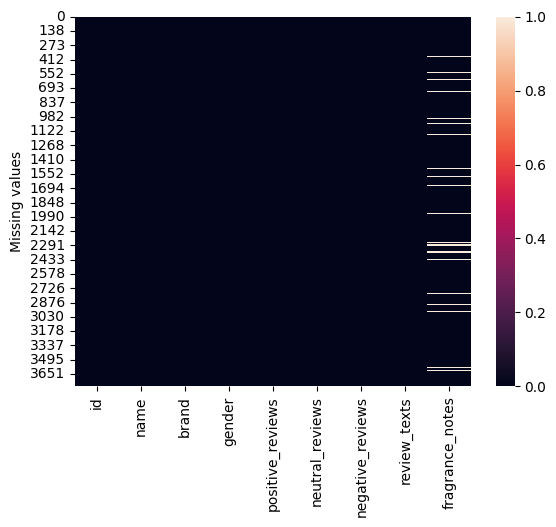

In [161]:
ax = plt.axes()
sns.heatmap(df.isna(), ax=ax)
plt.ylabel('Missing values')
plt.show()

In [162]:
df.dropna(subset=['fragrance_notes'], inplace=True)

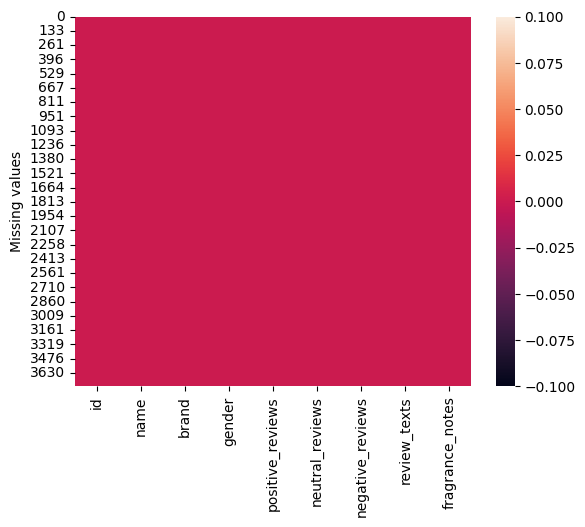

In [163]:
ax = plt.axes()
sns.heatmap(df.isna(), ax=ax)
plt.ylabel('Missing values')
plt.show()

In [164]:
df['review_texts']

0       ["I felt incredibly disappointed by this scent...
1       ["My wife is a lover of Chypre fragrances star...
2       ["What to say about this classic that hasn't a...
3       ["I knew I HAD to sample this after reading on...
4       ["Generic \"shower gel\" soap smell with terri...
                              ...                        
3788    ["It opens with a sweetness that consists of s...
3789    ["Just perfect! Happy and simple smell! My fra...
3790    ["Another day, another 60s green chypre. Where...
3791    ["The opening is a fruity affair, steamed peac...
3792    ["If I could give this a 3.5, rather than eith...
Name: review_texts, Length: 3296, dtype: str

In [190]:
df_test = df['review_texts'].str.strip('[],""')


In [191]:
df_test.sample(10)

3334    I have a soft spot for pie-spiced lavender fou...
781     The only Tommy Bahama fragrance that I found c...
1779    It actually irks me to say I can't help but fe...
2567    Simple yet Brilliant, This was a love at first...
2402    Freshly woody-aquatic with a bit of peppery bi...
3218    Starts with a burst of Prell Shampoo scent, bu...
3002    Red's Wife: First it smells like perfume. Then...
225     Either nobody else noticed or nobody else care...
2523    Reminicent of Charlie, this is a nice, solid s...
2338    When I talk about a recent fragrance I've purc...
Name: review_texts, dtype: str